# <center>🏎️ Formula 1 - Race Outcome Prediction</center>
#### Dataset: [Comprehensive Formula 1 Dataset (2020–2025) — Kaggle](https://www.kaggle.com/datasets/vshreekamalesh/comprehensive-formula-1-dataset-2020-2025)

## Import:

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

# Data
df = pd.read_csv('f1_2024_race_results.csv')

# Normalize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df

,race_id,race_name,circuit,city,country,circuit_length_km,total_laps,position,driver_name,team,nationality,car_number,race_time,points,fastest_lap,pole_position
0,1,Bahrain Grand Prix,Bahrain International Circuit,Sakhir,Bahrain,5.412,57,1,Max Verstappen,Red Bull Racing,NED,1,1:35:17.520,25,No,Yes
1,1,Bahrain Grand Prix,Bahrain International Circuit,Sakhir,Bahrain,5.412,57,2,Lewis Hamilton,Mercedes,GBR,44,+11.472,18,No,No
2,1,Bahrain Grand Prix,Bahrain International Circuit,Sakhir,Bahrain,5.412,57,3,Carlos Sainz,Ferrari,ESP,55,+18.138,15,No,No
3,1,Bahrain Grand Prix,Bahrain International Circuit,Sakhir,Bahrain,5.412,57,4,Sergio Perez,Red Bull Racing,MEX,11,+84.310,12,Yes,No
4,1,Bahrain Grand Prix,Bahrain International Circuit,Sakhir,Bahrain,5.412,57,5,George Russell,Mercedes,GBR,63,+45.823,10,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,24,Abu Dhabi Grand Prix,Yas Marina Circuit,Abu Dhabi,UAE,5.281,58,16,Kevin Magnussen,Haas,DEN,20,+1 laps,0,No,No
476,24,Abu Dhabi Grand Prix,Yas Marina Circuit,Abu Dhabi,UAE,5.281,58,17,Logan Sargeant,Williams,USA,2,+2 laps,0,No,No
477,24,Abu Dhabi Grand Prix,Yas Marina Circuit,Abu Dhabi,UAE,5.281,58,18,Daniel Ricciardo,RB,AUS,3,+2 laps,0,No,No
478,24,Abu Dhabi Grand Prix,Yas Marina Circuit,Abu Dhabi,UAE,5.281,58,19,Zhou Guanyu,Kick Sauber,CHN,24,+2 lap,0,No,No


## Data Preprocessing & Cleaning:

In [2]:
# Column detection
POSITION_COL    = next((c for c in df.columns if c in ['position','finish','finishing_position','pos']), None)
GRID_COL        = next((c for c in df.columns if c in ['grid','grid_position','starting_grid','start_position']), None)
DRIVER_COL      = next((c for c in df.columns if c in ['driver','driver_name','driverid']), None)
CONSTRUCTOR_COL = next((c for c in df.columns if c in ['constructor','team','car','constructorid']), None)
POINTS_COL      = next((c for c in df.columns if c in ['points','pts']), None)

print('Detected columns:')
print(f'  Position    : {POSITION_COL}')
print(f'  Grid        : {GRID_COL}')
print(f'  Driver      : {DRIVER_COL}')
print(f'  Constructor : {CONSTRUCTOR_COL}')
print(f'  Points      : {POINTS_COL}')

Detected columns:
  Position    : position
  Grid        : None
  Driver      : driver_name
  Constructor : team
  Points      : points


In [3]:
# Keep only the needed columns and rename them
keep = {k: v for k, v in {
    POSITION_COL   : 'position',
    GRID_COL       : 'grid',
    DRIVER_COL     : 'driver',
    CONSTRUCTOR_COL: 'constructor',
    POINTS_COL     : 'points'
}.items() if k is not None}

df = df[list(keep.keys())].rename(columns=keep)

# Convert numeric columns
for col in ['position', 'grid', 'points']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Handle missing values
df.ffill(inplace=True)
required = [c for c in ['position', 'grid'] if c in df.columns]
df.dropna(subset=required, inplace=True)

# Fallback
if 'grid' not in df.columns:
    
    df['grid'] = df['position']

df['position'] = df['position'].astype(int)
df['grid']     = df['grid'].round().astype(int)

# Create binary classification target
df['top10'] = (df['position'] <= 10).astype(int)

df

,position,driver,constructor,points,grid,top10
0,1,Max Verstappen,Red Bull Racing,25,1,1
1,2,Lewis Hamilton,Mercedes,18,2,1
2,3,Carlos Sainz,Ferrari,15,3,1
3,4,Sergio Perez,Red Bull Racing,12,4,1
4,5,George Russell,Mercedes,10,5,1
...,...,...,...,...,...,...
475,16,Kevin Magnussen,Haas,0,16,0
476,17,Logan Sargeant,Williams,0,17,0
477,18,Daniel Ricciardo,RB,0,18,0
478,19,Zhou Guanyu,Kick Sauber,0,19,0


In [4]:
# Encode driver and constructor as numbers
le = LabelEncoder()

df['driver_enc']      = le.fit_transform(df['driver'].astype(str))      if 'driver'      in df.columns else 0
df['constructor_enc'] = le.fit_transform(df['constructor'].astype(str)) if 'constructor' in df.columns else 0

## Visualizations:

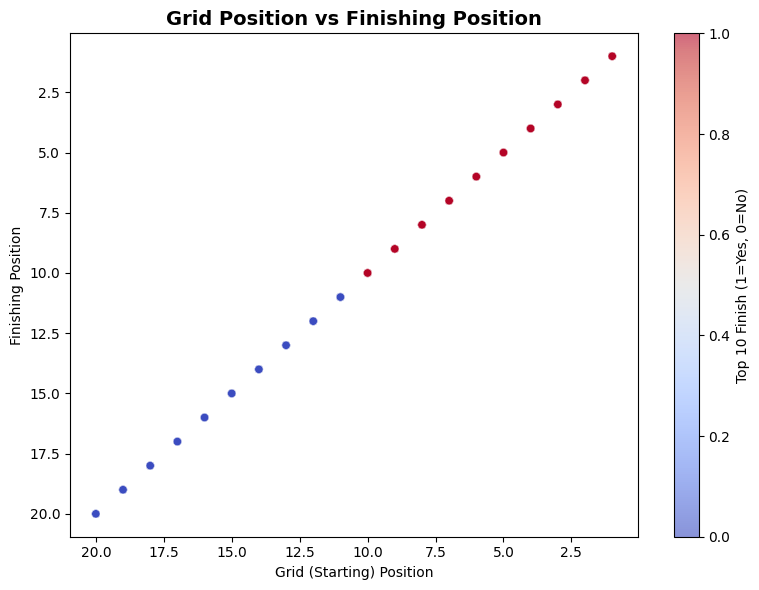

In [5]:
# Plot 1: Grid Position vs Finishing Position
# Drivers starting near the front tend to finish near the front.
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df['grid'], df['position'],
    c=df['top10'], cmap='coolwarm',
    alpha=0.6, edgecolors='white', linewidths=0.4
)
plt.colorbar(scatter, label='Top 10 Finish (1=Yes, 0=No)')
plt.xlabel('Grid (Starting) Position')
plt.ylabel('Finishing Position')
plt.title('Grid Position vs Finishing Position', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

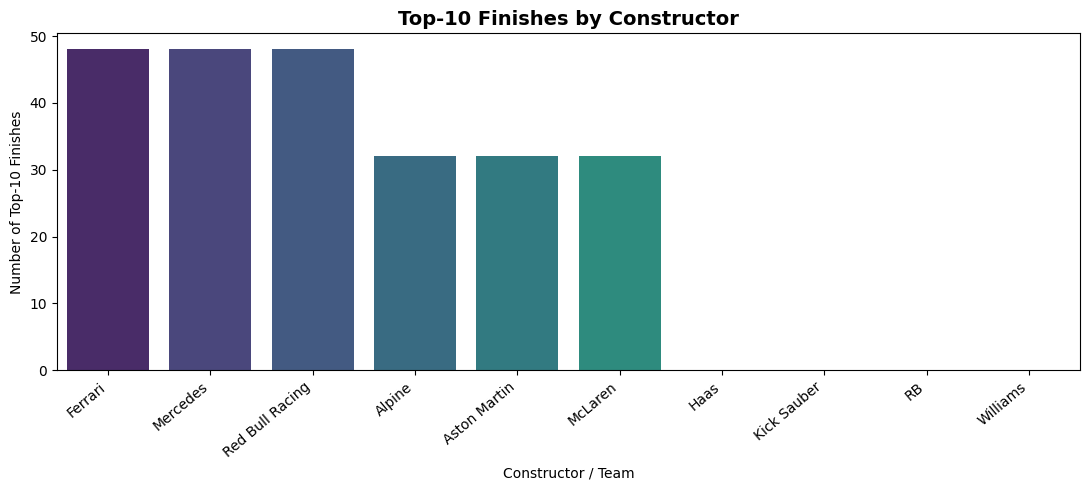

In [6]:
# Plot 2: Top-10 Finishes by Constructor
# Shows which teams are most competitive.
if 'constructor' in df.columns:
    top10_by_team = df.groupby('constructor')['top10'].sum().sort_values(ascending=False)

    plt.figure(figsize=(11, 5))
    sns.barplot(x=top10_by_team.index, y=top10_by_team.values, palette='viridis')
    plt.title('Top-10 Finishes by Constructor', fontsize=14, fontweight='bold')
    plt.xlabel('Constructor / Team')
    plt.ylabel('Number of Top-10 Finishes')
    plt.xticks(rotation=40, ha='right')
    plt.tight_layout()
    plt.show()

## Problem Formulation:

In [7]:
# Define features
features = ['grid', 'driver_enc', 'constructor_enc']
if 'points' in df.columns:
    features.append('points')

X = df[features]
y_reg = df['position']   
y_clf = df['top10']      

# 80/20 train-test split
X_train, X_test, y_reg_train, y_reg_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)
X_train, X_test, y_clf_train, y_clf_test = train_test_split(X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')
print(f'Features used    : {features}')

Training samples : 384
Testing samples  : 96
Features used    : ['grid', 'driver_enc', 'constructor_enc', 'points']


## Model 1 (Linear Regression)

In [8]:
# Train the model
lr = LinearRegression()
lr.fit(X_train, y_reg_train)

# Predict on test set
y_reg_pred = lr.predict(X_test)

# Evaluate
mse  = mean_squared_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mse)
r2   = lr.score(X_test, y_reg_test)

print('Linear Regression Results')
print(f'  MSE  : {mse:.2f}')
print(f'  RMSE : {rmse:.2f}')
print(f'  R²   : {r2:.2f}')

Linear Regression Results
  MSE  : 37.85
  RMSE : 6.15
  R²   : -0.03


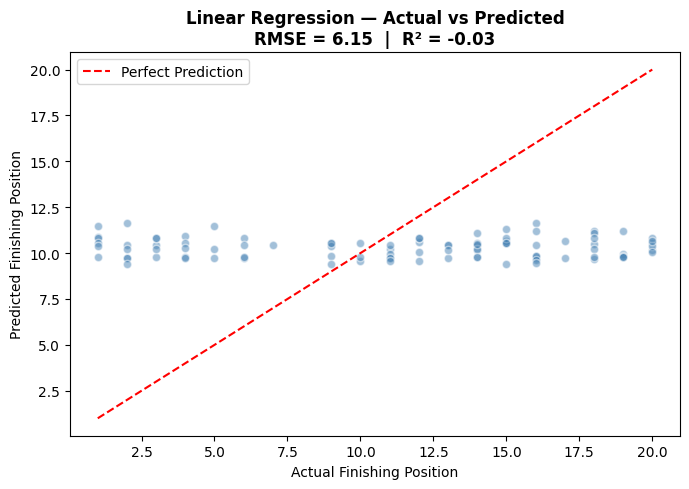

In [9]:
# Plot: Actual vs Predicted finishing position
plt.figure(figsize=(7, 5))
plt.scatter(y_reg_test, y_reg_pred, alpha=0.5, color='steelblue', edgecolors='white')
mn, mx = int(min(y_reg_test.min(), y_reg_pred.min())), int(max(y_reg_test.max(), y_reg_pred.max()))
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect Prediction')
plt.xlabel('Actual Finishing Position')
plt.ylabel('Predicted Finishing Position')
plt.title(f'Linear Regression — Actual vs Predicted\nRMSE = {rmse:.2f}  |  R² = {r2:.2f}', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## Model 2 (Decision Tree Classifier)

In [10]:
# Train the model
dtc = DecisionTreeClassifier(max_depth=5, random_state=42)
dtc.fit(X_train, y_clf_train)

# Predict on test set
y_clf_pred = dtc.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_clf_test, y_clf_pred)

print('Decision Tree Classifier Results')
print(f'  Accuracy: {accuracy*100:.1f}%')
print()
print(classification_report(y_clf_test, y_clf_pred, target_names=['Outside Top 10', 'Top 10']))

Decision Tree Classifier Results
  Accuracy: 100.0%

                precision    recall  f1-score   support

Outside Top 10       1.00      1.00      1.00        48
        Top 10       1.00      1.00      1.00        48

      accuracy                           1.00        96
     macro avg       1.00      1.00      1.00        96
  weighted avg       1.00      1.00      1.00        96



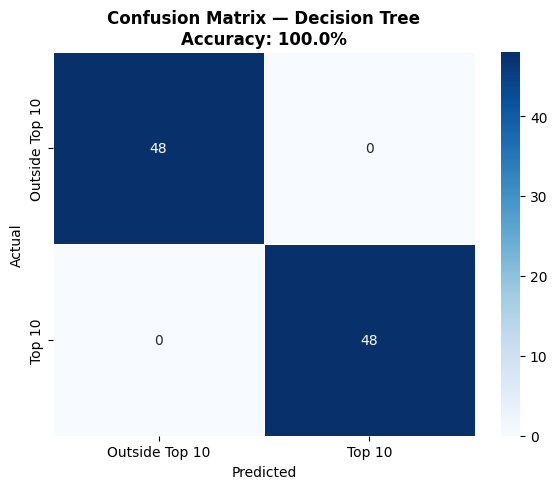

In [11]:
# Plot: Confusion Matrix
cm = confusion_matrix(y_clf_test, y_clf_pred)
labels = ['Outside Top 10', 'Top 10']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, linewidths=0.5)
plt.title(f'Confusion Matrix — Decision Tree\nAccuracy: {accuracy*100:.1f}%', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

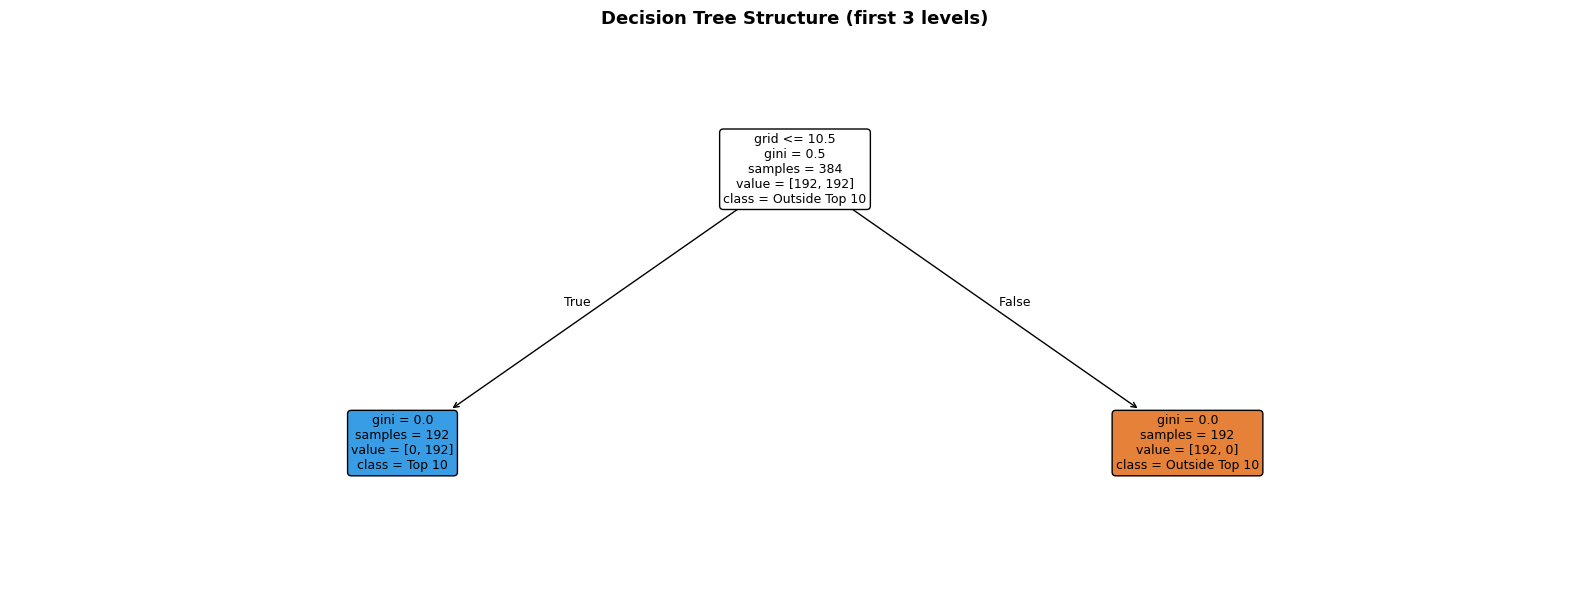

In [12]:
# Plot: Decision Tree Structure
plt.figure(figsize=(16, 6))
plot_tree(
    dtc, max_depth=3,
    feature_names=features,
    class_names=['Outside Top 10', 'Top 10'],
    filled=True, rounded=True, fontsize=9
)
plt.title('Decision Tree Structure (first 3 levels)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Performance Summary:

In [13]:
summary = pd.DataFrame({
    'Model'  : ['Linear Regression', 'Decision Tree Classifier'],
    'Task'   : ['Regression — Predict Finishing Position', 'Classification — Predict Top-10 Finish'],
    'Metric' : ['MSE / RMSE / R²', 'Accuracy'],
    'Result' : [f'MSE={mse:.2f},  RMSE={rmse:.2f},  R²={r2:.2f}', f'{accuracy*100:.1f}%']
})

print('Final Performance Summary')
display(summary)

Final Performance Summary


,Model,Task,Metric,Result
0,Linear Regression,Regression — Predict Finishing Position,MSE / RMSE / R²,"MSE=37.85, RMSE=6.15, R²=-0.03"
1,Decision Tree Classifier,Classification — Predict Top-10 Finish,Accuracy,100.0%


## Project Conclusion:
- **Grid position** is the strongest predictor of race outcome — drivers who qualify near the front tend to finish near the front.
- **Constructor / team** also plays a significant role, as car performance directly affects finishing position.
- The **classification model** (Top-10 prediction) performs well, showing these two features are strong predictors.
- The **regression model** shows moderate error — race outcomes are not perfectly predictable due to randomness like crashes, pit stop strategies, and weather.

## Future Work

- Add a **Random Forest** model for improved accuracy
- Include **weather conditions** and **pit stop data** as additional features
- Apply **hyperparameter tuning** with GridSearchCV
- Explore **time-series modeling** to analyze lap-by-lap race progression

---
**References:**  
- [Kaggle Dataset](https://www.kaggle.com/datasets/vshreekamalesh/comprehensive-formula-1-dataset-2020-2025)  
- [Scikit-learn Documentation](https://scikit-learn.org/)